# <img src="./assets/course-icon.png" style="height:50px;display:inline"> ECE 046211 - Technion - Deep Learning
---

#### <a href="https://taldatech.github.io">Tal Daniel</a>

## Tutorial 05 - Multilayer Neural Networks
---
<center><img src="./assets/mlp.jpg" style="height:200px"></center>

### <img src="https://img.icons8.com/bubbles/50/000000/checklist.png" style="height:50px;display:inline"> Agenda
---

* [Multi-Layer Perceptron (MLP)](#-Multi-Layer-Perceptron-(MLP))
* [Modular Approach - Autodiff Reverse Mode](#-Modular-Approach---Autodiff-Reverse-Mode)
* [Example - Neural Networks for Regression - Housing Prices](#-Example---Neural-Networks-for-Regression---Housing-Prices)
* [Building a Neural Network with PyTorch](#-Building-a-Neural-Network-with-PyTorch)
* [Weights Initialization](#-Weights-Initialization)
* [Neural Network Weight Initialization with PyTorch](#-Neural-Network-Weight-Initialization-with-PyTorch)
* [Deep Double Descent](#-Deep-Double-Descent)
* [Recommended Videos](#-Recommended-Videos)
* [Credits](#-Credits)

#### <img src="./assets/colab_icon.PNG" style="height:30px;display:inline"> Additional Packeges for Google Colab
----
If you are using <a href="https://colab.research.google.com/">Google Colab</a>, you have to install additional packages. To do this, simply run the following cell.

In [1]:
# to work locally (win/linux/mac), first install 'graphviz': https://graphviz.org/download/ and restart your machine
!pip install torchviz

In [2]:
# imports for the tutorial
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import torchviz
from sklearn.datasets import load_boston
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
# %matplotlib notebook
%matplotlib inline

<!-- ### <img src="https://img.icons8.com/dusk/64/000000/layers.png" style="height:50px;display:inline"> Multi-Layer Perceptron (MLP)
---
* An MLP is composed of one input layer, one or more hidden layers and a final output layer. 
* Every layer, except the output layer, optionally includes a **bias neuron** which is fully connected to the next layer. 
* When the number of hidden layers is larger than 2, the network is usually called a deep neural network (DNN). -->

<!-- ### <img src="https://img.icons8.com/dusk/64/000000/layers.png" style="height:50px;display:inline"> Multi-Layer Perceptron (MLP)
---
<div style="width:100%;height:800px;line-height:3em;overflow:scroll;padding:5px;">

* An MLP is composed of
    * One <ins>input layer</ins> 
    * One (or more) <ins>hidden layers</ins> 
    * One <ins>output layer</ins>
* Every layer, except the output layer, optionally includes a **bias neuron** which is fully connected to the next layer. 
* When the number of hidden layers is larger than 2, the network is usually called a <ins>deep neural network</ins> (DNN).
<center><img src="./assets/mlp_example.jpg" style="height:300px"></center>

* MLPs are trained with the *backpropgation* algorithm, which is composed of two main parts: (1) **Forward pass**  and (2) **backward pass**.
    * This **autodiff reverse mode**.
* In the *forward pass*, for each training instance, the algorithm feeds it to the network and computes the output of every neuron in each consecutive layer (using the network for prediction is just doing a forward pass). 
* Then, the output error (the difference between the desired output and the actual output from the network), which is task dependent, is computed.

* After the output error calculation, the network calculates how much each neuron in the last hidden layer contributed to the output error (using the **chain rule**).
* It then proceeds to measure how much of these error contributions came from each neuron in the previous layers until reaching the input layer. 
* This is the *backward pass*: measuring the error gradient across all the connection weights in the network by propagating the error gradient backward in the network (this is the backpropagation process).

In short: for each training instance (=batch) the **backpropagation algorithm** first makes a prediction (forward pass), measures the error, then goes in reverse to measure the error contribution from each connection (backward pass) and finally, using Gradient Descent, updates the weights in the direction that reduces the error.

<center><img src="./assets/mlp_anim.gif" style="height:300px"></center>

<a href="https://medium.com/the-feynman-journal/the-linear-and-nonlinear-nature-of-feedforward-84199eb3edea">Image Source</a>

<center><img src="./assets/mlp_example.jpg" style="height:300px"></center>

For example, if: $$ X \in \mathbb{R}^2 $$ $$ W_1 \in \mathbb{R}^{2 \times 4} $$ $$ W_2 \in \mathbb{R}^{4 \times 3} $$ $$ W_3 \in \mathbb{R}^{3 \times 1} $$ $$ b_1 \in \mathbb{R}^4 $$ $$ b_2 \in \mathbb{R}^3 $$ $$ b_3 \in \mathbb{R} $$ Then: $$ F(X,W) = W_3^T \phi_2(W_2^T\phi_1(W_1^TX + b_1) + b_2) + b_3 $$
</div> -->

### <img src="https://img.icons8.com/dusk/64/000000/layers.png" style="height:50px;display:inline"> Multi-Layer Perceptron (MLP)
---
<div style="width:100%;height:800px;line-height:2em;overflow:scroll;padding:5px;">

* An MLP is made of:
  * One **input layer**
  * One or more **hidden layers**
  * One **output layer**

* Hidden layers may include a **bias neuron** connected to the next layer.

* If there are more than 2 hidden layers, the network is called a **deep neural network** (DNN).

<center><img src="./assets/mlp_example.jpg" style="height:300px"></center>

* MLPs are trained with **backpropagation**, which has two steps:
  * **Forward pass**
  * **Backward pass** (using **autodiff reverse mode**)

* In the **forward pass**, each input flows through the network to produce an output.

* The output error (difference between prediction and target) is then computed.

* In the **backward pass**, the network calculates how each neuron contributed to the error using the **chain rule**.

* Errors are propagated backward layer-by-layer to adjust the weights.

* **Gradient Descent** updates the weights to reduce the error.

<center><img src="./assets/mlp_anim.gif" style="height:300px"></center>

<a href="https://medium.com/the-feynman-journal/the-linear-and-nonlinear-nature-of-feedforward-84199eb3edea">Image Source</a>

<center><img src="./assets/mlp_example.jpg" style="height:400px"></center>

Example:

$$ X \in \mathbb{R}^2,\quad W_1 \in \mathbb{R}^{2\times4},\quad W_2 \in \mathbb{R}^{4\times3},\quad W_3 \in \mathbb{R}^{3\times1} $$  
$$ b_1 \in \mathbb{R}^4,\quad b_2 \in \mathbb{R}^3,\quad b_3 \in \mathbb{R} $$  

Then:

$$ F(X,W) = W_3^T \phi_2(W_2^T\phi_1(W_1^TX + b_1) + b_2) + b_3 $$
</div>


### Common Activation Functions
The key change made to the Perceptron that brought upon the era of deep learning is the addition of **activation function** to the output of each neuron. These allow the learning of non-linear functions. Some popular activation functions:

<div style="display: flex; justify-content: space-between;">
  <div style="width: 55%;">
    <h3></h3>
    <p>
<div style="width:100%;height:600px;line-height:3em;overflow:scroll;padding:5px;">

1. **Logistic (Sigmoid)**:     $\sigma(z) = \frac{1}{1 + e^{-z}}$  
   - Output: $[0, 1]$ (for probabilities, binary classification)  
   - PyTorch: [`nn.Sigmoid()`](https://pytorch.org/docs/stable/generated/torch.nn.Sigmoid.html) or `torch.sigmoid()`  
2. **Hyperbolic Tangent (Tanh)**:     $tanh(z) = 2\sigma(2z) - 1$  
   - Output: $[-1, 1]$ (normalizes layer outputs)  
   - PyTorch: [`nn.Tanh()`](https://pytorch.org/docs/stable/generated/torch.nn.Tanh.html) or `torch.tanh()`  

3. **ReLU (Rectified Linear Unit)**:     $ReLU(z) = \max(0, z)$  
   - Fast, unbounded output, common in deep networks  
   - PyTorch: [`nn.ReLU()`](https://pytorch.org/docs/stable/generated/torch.nn.ReLU.html) or `torch.relu()`  

4. **LeakyReLU**:     $LeakyReLU(z) = \max(0, z) + \text{negative\_slope} \cdot \min(0, z)$  
   - Small negative slope prevents sparse gradients  
   - PyTorch: [`nn.LeakyReLU(negative_slope=0.01)`](https://pytorch.org/docs/stable/generated/torch.nn.LeakyReLU.html)  

   *Also: **ELU** — [`nn.ELU(alpha=1.0)`](https://pytorch.org/docs/stable/generated/torch.nn.ELU.html)*  

5. **Gaussian Error Linear Unit (GELU)**:     $GELU(x) = x \cdot \Phi(x)$, where $\Phi(x)$ is the Gaussian CDF  
   - Smooth, widely used in Transformer models  
   - PyTorch: [`nn.GELU()`](https://pytorch.org/docs/stable/generated/torch.nn.GELU.html) | [Details](https://paperswithcode.com/method/gelu)  

6. **Sigmoid Linear Unit (SiLU)**:     $SiLU(x) = x \cdot \sigma(x)$  
   - PyTorch: [`nn.SiLU()`](https://pytorch.org/docs/stable/generated/torch.nn.SiLU.html)
</div></p>
  </div>
  <div style="flex: 0 0 48%;">
    <h3></h3>
    <p>
        <!-- <center><img src="./assets/activation_functions.png" style="height:400px"></center> -->
        <center><img src="./assets/activation_functions_v.png" style="width:100%"></center>

    </p>
  </div>
</div>


<!-- The key change made to the Perceptron that brought upon the era of deep learning is the addition of **activation function** to the output of each neuron. These allow the learning of non-linear functions. Some popular activation functions:
1. **Logistic function (sigmoid)**: $\sigma(z) = \frac{1}{1 + e^{-z}}$. The output is in $[0,1]$ which can be used for binary classification or as a probability. In PyTorch: <a href="https://pytorch.org/docs/stable/generated/torch.nn.Sigmoid.html">`nn.Sigmoid()` or `torch.sigmoid()`</a>.
2. **Hyperbolic tangent function**: $tanh(z) = 2\sigma(2z) - 1$. The output is in $[-1,1]$ which tends to make each layer's output more or less normalized at the beginning of the training (which may speed up convergence). In PyTorch: <a href="https://pytorch.org/docs/stable/generated/torch.nn.Tanh.html">`nn.Tanh()` or `torch.tanh()`</a>.
3. **ReLU (Rectified Linear Unit) function**: $ReLU(z) = \max(0,z)$. Continuous but not differentiable at $z=0$. However, it is the most common activation function as it is fast to compute and does not bound the output (which helps with some issues during Gradient Descent). In PyTorch: <a href="https://pytorch.org/docs/stable/generated/torch.nn.ReLU.html">`nn.ReLU()` or `torch.relu()`</a>.
4. **LeakyReLU function**: $LeakyReLU(z) = \max(0,x) + \text{negative-slope} * \min(0,x)$. An activation function based on a ReLU, but it has a small slope for negative values instead of a flat slope. The slope coefficient is a hyper-parameter determined before training. This type of activation function is popular in tasks where we we may suffer from sparse gradients. In PyTorch: <a href="https://pytorch.org/docs/stable/generated/torch.nn.LeakyReLU.html">`nn.LeakyReLU(negative_slope=0.01)`</a>.
    * Also see **Exponential Linear Unit (ELU)**: In PyTorch: <a href="https://pytorch.org/docs/stable/generated/torch.nn.ELU.html">`nn.ELU(alpha=1.0)`</a>.
5. **Gaussian Error Linear Units (GELU) function**: $GELU(x) = x * \Phi(x)$, where $\Phi(x)$ is the Cumulative Distribution Function (CDF) for the standard Gaussian Distribution. In PyTorch: <a href="https://pytorch.org/docs/stable/generated/torch.nn.GELU.html">`nn.GELU()`</a>. <a href="https://paperswithcode.com/method/gelu">Read More</a>.
6. **Sigmoid Linear Unit (SiLU) function**: $silu(x) = x * \sigma(x)$. In PyTorch: <a href="https://pytorch.org/docs/stable/generated/torch.nn.SiLU.html">`nn.SiLU()`</a>. -->

<!-- <img src="./assets/tut_mlp_activations.PNG" style="height:500px"> -->

<!-- ### Common Activation Functions
<div style="width:100%;height:800px;line-height:3em;overflow:scroll;padding:5px;">

The key change made to the Perceptron that brought upon the era of deep learning is the addition of **activation function** to the output of each neuron. These allow the learning of non-linear functions. Some popular activation functions:
1. **Logistic (Sigmoid)**:     $\sigma(z) = \frac{1}{1 + e^{-z}}$  
   - Output: $[0, 1]$ (for probabilities, binary classification)  
   - PyTorch: [`nn.Sigmoid()`](https://pytorch.org/docs/stable/generated/torch.nn.Sigmoid.html) or `torch.sigmoid()`  
2. **Hyperbolic Tangent (Tanh)**:     $tanh(z) = 2\sigma(2z) - 1$  
   - Output: $[-1, 1]$ (normalizes layer outputs)  
   - PyTorch: [`nn.Tanh()`](https://pytorch.org/docs/stable/generated/torch.nn.Tanh.html) or `torch.tanh()`  

3. **ReLU (Rectified Linear Unit)**:     $ReLU(z) = \max(0, z)$  
   - Fast, unbounded output, common in deep networks  
   - PyTorch: [`nn.ReLU()`](https://pytorch.org/docs/stable/generated/torch.nn.ReLU.html) or `torch.relu()`  

4. **LeakyReLU**:     $LeakyReLU(z) = \max(0, z) + \text{negative\_slope} \cdot \min(0, z)$  
   - Small negative slope prevents sparse gradients  
   - PyTorch: [`nn.LeakyReLU(negative_slope=0.01)`](https://pytorch.org/docs/stable/generated/torch.nn.LeakyReLU.html)  

   *Also: **ELU** — [`nn.ELU(alpha=1.0)`](https://pytorch.org/docs/stable/generated/torch.nn.ELU.html)*  

5. **Gaussian Error Linear Unit (GELU)**:     $GELU(x) = x \cdot \Phi(x)$, where $\Phi(x)$ is the Gaussian CDF  
   - Smooth, widely used in Transformer models  
   - PyTorch: [`nn.GELU()`](https://pytorch.org/docs/stable/generated/torch.nn.GELU.html) | [Details](https://paperswithcode.com/method/gelu)  

6. **Sigmoid Linear Unit (SiLU)**:     $SiLU(x) = x \cdot \sigma(x)$  
   - PyTorch: [`nn.SiLU()`](https://pytorch.org/docs/stable/generated/torch.nn.SiLU.html)
</div> -->

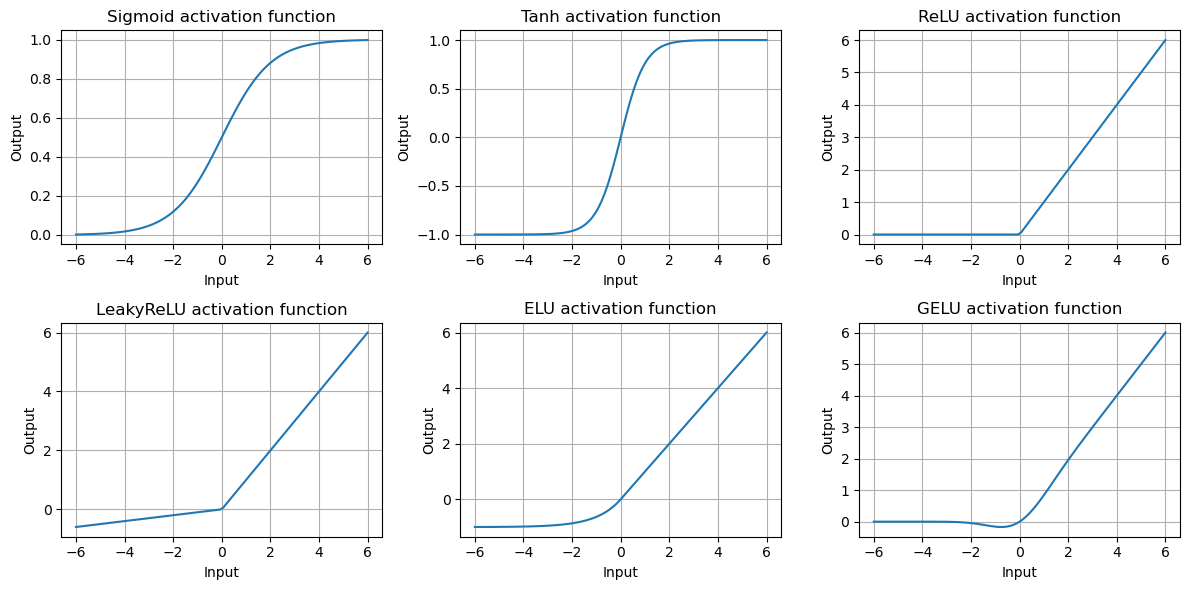

In [3]:
# Define input range as a PyTorch tensor
x = torch.linspace(-6, 6, 100)

# Create subplots
plt.figure(figsize=(12, 6))
# plt.figure(figsize=(8, 8))
functions = [
    (torch.sigmoid, "Sigmoid activation function"),
    (torch.tanh, "Tanh activation function"),
    (F.relu, "ReLU activation function"),
    (lambda x: F.leaky_relu(x, negative_slope=0.1), "LeakyReLU activation function"),
    (F.elu, "ELU activation function"),
    (F.gelu, "GELU activation function"),
]

# Plot each activation function
for i, (func, title) in enumerate(functions):
    plt.subplot(2, 3, i + 1)
    # plt.subplot(3, 2, i + 1)
    plt.plot(x.numpy(), func(x).numpy())
    plt.title(title)
    plt.xlabel("Input")
    plt.ylabel("Output")
    plt.grid(True)

plt.tight_layout()
plt.show()

## <img src="https://img.icons8.com/dusk/64/000000/lego-head.png" style="height:50px;display:inline"> Modular Approach - Autodiff Reverse Mode
---
<div style="width:100%;height:700px;line-height:3em;overflow:scroll;padding:5px;">

<div style="display: flex; justify-content: space-between;">
  <div style="width: 55%;">
    <h3></h3>
    <p>

* We code **layers**, not networks.
* Layer Specification - each layer needs to provide 3 functions:
    1. The layer output given its input (forward pass) $Z^{(k+1)} = f(Z^{(k)}) $.
    2. Derivative with respect to the input $  \frac{\partial Z^{(k+1)}}{\partial Z^{(k)}} $.
    3. Derivative with respect to parameters $  \frac{\partial Z^{(k+1)}}{\partial W^{(k)}} $.

    </p>
  </div>
  <div style="width: 40%; padding-left: 10px;">
    <p><center><img src="./assets/modular_approach_1.jpg" style="width:70%"></center></p>
  </div>
</div>
<center><img src="./assets/modular_approach_2.jpg" style="height:300px"></center>

<center><img src="./assets/local_gradient.png" style="height:300px"></center>

Image source: CS231n Lecture 4
</div>

<!-- 
## <img src="https://img.icons8.com/dusk/64/000000/lego-head.png" style="height:50px;display:inline"> Modular Approach - Autodiff Reverse Mode
---
<div style="width:100%;height:700px;line-height:3em;overflow:scroll;padding:5px;">

* We code **layers**, not networks.
* Layer Specification - each layer needs to provide 3 functions:
    1. The layer output given its input (forward pass) $Z^{(k+1)} = f(Z^{(k)}) $.
    2. Derivative with respect to the input $  \frac{\partial Z^{(k+1)}}{\partial Z^{(k)}} $.
    3. Derivative with respect to parameters $  \frac{\partial Z^{(k+1)}}{\partial W^{(k)}} $.
       
<be>
Illustration: <center><img src="./assets/modular_approach_1.jpg" style="height:450px"></center>

Zoom-in: <center><img src="./assets/modular_approach_2.jpg" style="height:300px"></center>

<center><img src="./assets/local_gradient.png" style="height:300px"></center>

Image source: CS231n Lecture 4
</div> -->

<!-- ### <img src="https://img.icons8.com/plasticine/100/000000/serial-tasks.png" style="height:50px;display:inline"> Backpropagation
---
We now establish a common language when it comes to neural networks architecture (assume single dimension):
* **Forward Pass**: $Z^{(k+1)} = f(Z^{(k)}) $
* **Backward Pass**: $\delta^{(k+1)} = \frac{\partial E}{\partial Z^{(k+1)}}$
* Applying the **chain rule** for a single layer: $$ \frac{\partial E}{\partial Z^{(k)}} = \frac{\partial E}{\partial Z^{(k+1)}} \frac{\partial Z^{(k+1)}}{\partial Z^{(k)}} = \delta^{(k+1)}\frac{\partial Z^{(k+1)}}{\partial Z^{(k)}} = \delta^{(k+1)}\frac{\partial f(Z^{(k)})}{\partial Z^{(k)}} $$
* The **gradient with respect to layer parameters** (if it has any): $$ \frac{\partial E}{\partial W^{(k)}} = \frac{\partial E}{\partial Z^{(k+1)}} \frac{\partial Z^{(k+1)}}{\partial W^{(k)}} = \delta^{(k+1)} \frac{\partial Z^{(k+1)}}{\partial W^{(k)}}  $$

* **Important Note**: in the above, for multi-dimensional tensors, there is an abuse of dimensions above: $ \frac{\partial Z^{(k+1)}}{\partial W^{(k)}} $ is not the proper way of getting the derivative of "a vector w.r.t. a matrix". See explanation under the **The Linear Layer** section below. -->

### <img src="https://img.icons8.com/plasticine/100/000000/serial-tasks.png" style="height:50px;display:inline"> Backpropagation
---

<div style="width:100%;height:700px;line-height:3em;overflow:scroll;padding:5px;">
We now establish a common language when it comes to neural networks architecture (assume single dimension):

<div style="display: flex; justify-content: space-between;">
  <div style="width: 55%;">
    <p>

* **Forward Pass**:
    * <ins>Input</ins>: $ Z^{(k)}$
    * <ins>Output</ins>: $Z^{(k+1)} = f(Z^{(k)}) $

* **Backward Pass**:
    * <ins>Input</ins>: $\delta^{(k + 1)}$ (Gradient of the Loss w.r.t. layer's output)
    * <ins>Output</ins>: $\delta^{(k)} = \frac{\partial E}{\partial Z^{(k)}}$ (Gradient of the Loss w.r.t. input)

    </p>
</div>
  <div style="width: 40%; padding-left: 10px;">
    <p>  </br></br>
        <center><img src="./assets/modular_approach_2.jpg" style="width:90%"></center>
    </p>
  </div>
</div>

* * * Applying the **chain rule** for a single layer:        
          $$ \delta^{(k)} = \frac{\partial E}{\partial Z^{(k)}} = \frac{\partial E}{\partial Z^{(k+1)}} \frac{\partial Z^{(k+1)}}{\partial Z^{(k)}} = \delta^{(k+1)}\frac{\partial Z^{(k+1)}}{\partial Z^{(k)}} = \delta^{(k+1)}\frac{\partial f(Z^{(k)})}{\partial Z^{(k)}} $$
  * Additionaly, compute the **gradient with respect to layer parameters** (if it has any):
    $$ \frac{\partial E}{\partial W^{(k)}} = \frac{\partial E}{\partial Z^{(k+1)}} \frac{\partial Z^{(k+1)}}{\partial W^{(k)}} = \delta^{(k+1)} \frac{\partial Z^{(k+1)}}{\partial W^{(k)}}  $$

* **Important Note**: in the above, for multi-dimensional tensors, there is an abuse of dimensions above: $ \frac{\partial Z^{(k+1)}}{\partial W^{(k)}} $ is not the proper way of getting the derivative of "a vector w.r.t. a matrix". See explanation under the **The Linear Layer** section below.

<!-- ### <img src="https://img.icons8.com/plasticine/100/000000/serial-tasks.png" style="height:50px;display:inline"> Backpropagation
---
We now establish a common language when it comes to neural networks architecture (assume single dimension):
* **Forward Pass**:
    * <ins>Input</ins>: $ Z^{(k)}$
    * <ins>Output</ins>: $Z^{(k+1)} = f(Z^{(k)}) $

* **Backward Pass**:
    * <ins>Input</ins>: $\delta^{(k + 1)}$ (Gradient of the Loss w.r.t. layer's output)
    * <ins>Output</ins>: $\delta^{(k)} = \frac{\partial E}{\partial Z^{(k)}}$ (Gradient of the Loss w.r.t. input)


        * Applying the **chain rule** for a single layer:
          $$ \delta^{(k)} = \frac{\partial E}{\partial Z^{(k)}} = \frac{\partial E}{\partial Z^{(k+1)}} \frac{\partial Z^{(k+1)}}{\partial Z^{(k)}} = \delta^{(k+1)}\frac{\partial Z^{(k+1)}}{\partial Z^{(k)}} = \delta^{(k+1)}\frac{\partial f(Z^{(k)})}{\partial Z^{(k)}} $$
    * Additionaly, compute the **gradient with respect to layer parameters** (if it has any):
    $$ \frac{\partial E}{\partial W^{(k)}} = \frac{\partial E}{\partial Z^{(k+1)}} \frac{\partial Z^{(k+1)}}{\partial W^{(k)}} = \delta^{(k+1)} \frac{\partial Z^{(k+1)}}{\partial W^{(k)}}  $$

* **Important Note**: in the above, for multi-dimensional tensors, there is an abuse of dimensions above: $ \frac{\partial Z^{(k+1)}}{\partial W^{(k)}} $ is not the proper way of getting the derivative of "a vector w.r.t. a matrix". See explanation under the **The Linear Layer** section below. -->

### <img src="https://img.icons8.com/color/96/000000/3d-glasses.png" style="height:50px;display:inline"> Extension to Multi-Dimensions
---

<div style="width:100%;height:700px;line-height:3em;overflow:scroll;padding:5px;">

* $f: \mathbb{R}^n \to \mathbb{R}^m$ is a vector function of a vector variable: $$ f(x) = \begin{bmatrix} f_1(x) \\ \vdots \\ f_m(x) \end{bmatrix}, x \in \mathbb{R}^n, f(x) \in \mathbb{R}^m $$
* The **gradient** is given by: $$ \frac{\partial f_i}{\partial x} = \big[ \frac{\partial f_i(x)}{\partial x_1}, ..., \frac{\partial f_i(x)}{\partial x_n} \big] $$
* The **Jacobian**, $J_f(x) \in \mathbb{R}^{m \times n}$, is given by: $$ J_f(x) = \begin{bmatrix} \frac{\partial f_1(x)}{\partial x}\\ \vdots\\ \frac{\partial f_m(x)}{\partial x} \end{bmatrix} = \begin{bmatrix} \frac{\partial f_1}{\partial x_1} && \cdots && \frac{\partial f_1}{\partial x_n} \\ \vdots && \ddots && \vdots \\ \frac{\partial f_m}{\partial x_1} && \cdots && \frac{\partial f_m}{\partial x_n} \end{bmatrix} $$

* **The Chain Rule**:
    * Given: $$ F: \mathbb{R}^n \to \mathbb{R}^m $$ $$ \phi: \mathbb{R}^m \to \mathbb{R}^k $$ $$ \psi(x)= \phi(F(x)) $$
    * The Jacobian is given by: $$ J_{\psi} = J_{\phi} J_F $$ $$ J_{\phi} \in \mathbb{R}^{k \times m}, J_F \in  \mathbb{R}^{m \times n} \to J_{\psi} \in \mathbb{R}^{k \times n}$$
    * Recall that `autograd` implements reverse mode Autodiff as a vector-Jacobian multiplication engine.

<center><img src="./assets/backprop_anim.gif" style="height:350px"></center>
<a href="https://anatomiesofintelligence.github.io/posts/2018-10-16-forward-back-propogation">Image Source</a>  
</div>

#### Example

In [4]:
import torch
from torch.autograd import Function

class CustomLinearFunction(Function):
    @staticmethod
    def forward(ctx, input, weight, bias=None):
        """
        Forward pass of the linear layer.
        Computes output = input @ weight.T + bias (if provided).
        """
        ctx.save_for_backward(input, weight, bias)
        output = input.mm(weight.t())
        if bias is not None:
            output += bias
        return output

    @staticmethod
    def backward(ctx, grad_output):
        """
        Backward pass of the linear layer.
        Computes gradients of the loss with respect to input, weight, and bias.
        """
        input, weight, bias = ctx.saved_tensors
        grad_input = grad_output.mm(weight)  # Gradient w.r.t. input
        grad_weight = grad_output.t().mm(input)  # Gradient w.r.t. weight
        grad_bias = grad_output.sum(0) if bias is not None else None  # Gradient w.r.t. bias
        return grad_input, grad_weight, grad_bias


### <img src="https://img.icons8.com/dusk/64/000000/popular-topic.png" style="height:50px;display:inline"> Commonly Used Layers (as Modular Blocks)
---
* Linear Layer (linear combination of the inputs).
* Activation Layer (usually together with the linear layer, apply a function on the linear combination of weighted inputs): ReLU, Binary Step, Sigmoid, TanH and etc...
* Softmax Layer (Sigmoid for more than 2 classes, outputs the probability of each class) for classification tasks.
* Loss Function Layer (e.g., MSE and Cross Entropy).

## <img src="https://img.icons8.com/dusk/64/000000/home.png" style="height:50px;display:inline"> Example - Neural Networks for Regression - Housing Prices
---
<!-- <div style="width:100%;height:700px;line-height:3em;overflow:scroll;padding:5px;"> -->

* The Housing Prices Dataset:
    * Two input features: *Size* and *Floor*
    * One output: *House Price*
    * **Loss function**: MSE

## <img src="https://img.icons8.com/dusk/64/000000/home.png" style="height:50px;display:inline"> Example - Neural Networks for Regression - Housing Prices
---
<div style="width:100%;height:700px;line-height:3em;overflow:scroll;padding:5px;">

* The Housing Prices Dataset:
    * Two input features: *Size* and *Floor*
    * One output: *House Price*
    * **Loss function**: MSE
      
<div style="display: flex; width: 100%;">
  <div style="width: 50%; padding-right: 10px;"><p>

* Suggested **network architecture**: 2 hidden layers
    * Two inputs, one for each feature
    * Four neurons in the *first hidden layer*
    * Three neurons in the *second hidden layer*
    * One output
    </p>
  </div>
  <div style="width: 40%; padding-left: 10px;">
    <p>
        <center><img src="./assets/mlp_example.jpg" style="width:80%"></center> 
        
    </p>
  </div>
</div>

$$ F(X,W) = W_3^T \phi_2(W_2^T\phi_1(W_1^TX + b_1) + b_2) + b_3 $$
Where: $$ X \in \mathbb{R}^2 $$ $$ W_1 \in \mathbb{R}^{2 \times 4} $$ $$ W_2 \in \mathbb{R}^{4 \times 3} $$ $$ W_3 \in \mathbb{R}^{3 \times 1} $$ $$ b_1 \in \mathbb{R}^4 $$ $$ b_2 \in \mathbb{R}^3 $$ $$ b_3 \in \mathbb{R} $$
</div>

<!-- ## <img src="https://img.icons8.com/dusk/64/000000/home.png" style="height:50px;display:inline"> Example - Neural Networks for Regression - Housing Prices
---
<div style="width:100%;height:700px;line-height:3em;overflow:scroll;padding:5px;">

* The Housing Prices Dataset:
    * Two input features: *Size* and *Floor*
    * One output: *House Price*
    * **Loss function**: MSE
* Suggested **network architecture**: 2 hidden layers
    * Two inputs, one for each feature
    * Four neurons in the *first hidden layer*
    * Three neurons in the *second hidden layer*
    * One output

Layout: <center><img src="./assets/mlp_example.jpg" style="height:300px"></center> $$ F(X,W) = W_3^T \phi_2(W_2^T\phi_1(W_1^TX + b_1) + b_2) + b_3 $$

Where: $$ X \in \mathbb{R}^2 $$ $$ W_1 \in \mathbb{R}^{2 \times 4} $$ $$ W_2 \in \mathbb{R}^{4 \times 3} $$ $$ W_3 \in \mathbb{R}^{3 \times 1} $$ $$ b_1 \in \mathbb{R}^4 $$ $$ b_2 \in \mathbb{R}^3 $$ $$ b_3 \in \mathbb{R} $$
</div> -->

### <img src="https://img.icons8.com/office/80/000000/baby-footprints-path.png" style="height:50px;display:inline"> Step-by-Step Solution
---
<div style="width:100%;height:700px;line-height:3em;overflow:scroll;padding:5px;">

* <ins>Linear Layer</ins>: $$ u_{out} = W^Tu_{in} + b $$

* <ins>Activation Layer</ins>:
    * $\phi_1$ and $\phi_2$ are multivariate vector *nonlinear* functions, such that: $$ \phi(U) = \phi\left(\begin{bmatrix} u_1 \\ \vdots \\ u_n \end{bmatrix}\right) = \begin{bmatrix} \phi(u_1) \\ \vdots \\ \phi(u_n) \end{bmatrix} $$
    * For **ReLU**: $$ \begin{bmatrix} \phi(u_1) \\ \vdots \\ \phi(u_n) \end{bmatrix} = \begin{bmatrix} \max(0, u_1) \\ \vdots \\ \max(0, u_n) \end{bmatrix} $$ 

* <ins>Loss (MSE)</ins>
    * The MSE loss function over all the training examples $x_i$ and the corresponding training targets: $$ Error = \frac{1}{N} \sum_{i=1}^N (F(x_i, W) - y_i)^2 = \frac{1}{N} ||F(X, W) - Y||_2^2 $$

</div>

#### <img src="https://img.icons8.com/color/96/000000/layers.png" style="height:20px;display:inline"> The Linear Layer
---
<div style="width:100%;height:700px;line-height:3em;overflow:scroll;padding:5px;">

* **Forward Pass**: $$Z^{(k+1)} = f(Z^{(k)}) = (W^{(k)})^T Z^{(k)} + b^{(k)}.$$
    * $k$ denotes the $k^{th}$ layer with the corresponding weights and bias $W^{(k)}, b^{(k)}$.


* **Derivative** with respect to *input* $Z^{(k)}$: $$ \frac{\partial Z^{(k+1)}}{\partial Z^{(k)}} = \frac{\partial ((W^{(k)})^T Z^{(k)} + b^{(k)})}{\partial Z^{(k)}} = (W^{(k)})^T, $$ <br> $$ \delta^{(k)} = \delta^{(k+1)} (W^{(k)})^T . $$

* **Derivative** with respect to the *parameters*:
    * Weights $W^{(k)}$: We use a slightly different notation here: $\left( \frac{\partial E}{\partial W^{(k)}} \right)_{i,j} = \left( \frac{\partial E}{\partial W^{(k)}_{i,j}} \right)$
        * Note that entry $W^{(k)}_{i,j}$ only affects the output through $y_j$.
        * Therefore $$ \frac{\partial E}{\partial W^{(k)}_{i,j}} = \frac{\partial E}{\partial Z^{(k+1)}_j} \frac{\partial Z^{(k+1)}_j}{\partial W^{(k)}_{i,j}} = \delta^{(k+1)}_j Z^{(k)}_{i} $$
        *  We can write this in an outer product form:
          $$ \frac{\partial E}{\partial W^{(k)}} = Z^{(k)} \delta^{(k+1)^T} $$

      <!-- $$ \frac{\partial Z^{(k+1)}}{\partial W^{(k)}} = Z^{(k)} ,\frac{\partial E}{\partial W^{(k)}} = Z^{(k)} \delta^{(k+1)^T},  $$ -->

    * Bias  $b^{(k)}$: $$  \frac{\partial Z^{(k+1)}}{\partial b^{(k)}} = I,  \frac{\partial E}{\partial b^{(k)}} = \delta^{(k+1)}.$$

<br>

* **Important Note**: in the above, we *abused* the dimensions, e.g., $ \frac{\partial Z^{(k+1)}}{\partial W^{(k)}} = Z^{(k)} $ is not the proper way of getting the derivative of "a vector w.r.t. a matrix". The proper way of doing this calculation uses <a href="https://en.wikipedia.org/wiki/Kronecker_product">Kronecker product</a>: $ \frac{\partial(Ax)}{\partial A} = x \otimes I_m$, where $I_m$ is the $m \times m$ identity matrix. However, since we are starting our calculation from a scalar (our loss), the computation is simplified to a simple *outer product*: $\frac{\partial E}{\partial W^{(k)}} = Z^{(k)} \delta^{(k+1)^T}  $.
    * <a href="https://math.stackexchange.com/questions/1621948/derivative-of-a-vector-with-respect-to-a-matrix">"Derivative of a vector with respect to a matrix" @ math.stackexchange.com</a>.
    * <a href="http://cs231n.stanford.edu/vecDerivs.pdf">Vector, Matrix, and Tensor Derivatives - Erik Learned-Miller - page 4</a>.

* <a style='color:red'>**Tip**</a>: when calculating backpropagation by-hand, it is always good to perform calculations parameter-wise (i.e., calculate the gradient per parameter and not per layer) to avoid dimensionality issues.

</div>

<!-- #### <img src="https://img.icons8.com/color/96/000000/layers.png" style="height:20px;display:inline"> The Linear Layer
---
<div style="width:100%;height:700px;line-height:3em;overflow:scroll;padding:5px;">

* **Forward Pass**: $$Z^{(k+1)} = f(Z^{(k)}) = (W^{(k)})^T Z^{(k)} + b^{(k)}.$$
    * $k$ denotes the $k^{th}$ layer with the corresponding weights and bias $W^{(k)}, b^{(k)}$.

* **Derivative** with respect to *input* $Z^{(k)}$: $$ \frac{\partial Z^{(k+1)}}{\partial Z^{(k)}} = \frac{\partial ((W^{(k)})^T Z^{(k)} + b^{(k)})}{\partial Z^{(k)}} = (W^{(k)})^T, $$ <br> $$ \delta^{(k)} = \delta^{(k+1)} (W^{(k)})^T . $$

* **Derivative** with respect to the *parameters*:
    * Weights $W^{(k)}$:   $$ \frac{\partial Z^{(k+1)}}{\partial W^{(k)}} = Z^{(k)} ,\frac{\partial E}{\partial W^{(k)}} = Z^{(k)} \delta^{(k+1)^T},  $$ <br>
    * Bias  $b^{(k)}$: $$  \frac{\partial Z^{(k+1)}}{\partial b^{(k)}} = I,  \frac{\partial E}{\partial b^{(k)}} = \delta^{(k+1)}.$$

<br>

* **Important Note**: in the above, we *abused* the dimensions, e.g., $ \frac{\partial Z^{(k+1)}}{\partial W^{(k)}} = Z^{(k)} $ is not the proper way of getting the derivative of "a vector w.r.t. a matrix". The proper way of doing this calculation uses <a href="https://en.wikipedia.org/wiki/Kronecker_product">Kronecker product</a>: $ \frac{\partial(Ax)}{\partial A} = x \otimes I_m$, where $I_m$ is the $m \times m$ identity matrix. However, since we are starting our calculation from a scalar (our loss), the computation is simplified to a simple *outer product*: $\frac{\partial E}{\partial W^{(k)}} = Z^{(k)} \delta^{(k+1)^T}  $.
    * <a href="https://math.stackexchange.com/questions/1621948/derivative-of-a-vector-with-respect-to-a-matrix">"Derivative of a vector with respect to a matrix" @ math.stackexchange.com</a>.
    * <a href="http://cs231n.stanford.edu/vecDerivs.pdf">Vector, Matrix, and Tensor Derivatives - Erik Learned-Miller - page 4</a>.

* <a style='color:red'>**Tip**</a>: when calculating backpropagation by-hand, it is always good to perform calculations parameter-wise (i.e., calculate the gradient per parameter and not per layer) to avoid dimensionality issues.

</div> -->

####  <img src="https://img.icons8.com/color/96/000000/layers.png" style="height:20px;display:inline">  The ReLU Layer
---
<div style="width:100%;height:700px;line-height:3em;overflow:scroll;padding:5px;">

* **Forward Pass**: $$ Z^{(k+1)} = \begin{bmatrix} max(0,Z_1^{(k)}) \\ \vdots \\ max(0,Z_n^{(k)}) \end{bmatrix}, ReLU(Z): \mathbb{R}^{n} \to \mathbb{R}^n $$
* **Derivative** with respect to *input* $Z^{(k)}$: $$ \phi = max(0,Z^{(k)}), \phi' = heaviside(Z^{(k)}) $$ <br> $$ \frac{\partial Z^{(k+1)}}{\partial Z^{(k)}} = diag(\phi') $$ <br> $$ \delta^{(k)} = \delta^{(k+1)} diag (\phi') $$
* **Derivative** with respect to the *parameters*: **NO PARAMETERS!**

  </div>

####  <img src="https://img.icons8.com/color/96/000000/layers.png" style="height:20px;display:inline">  The MSE Layer 
---
<div style="width:100%;height:700px;line-height:3em;overflow:scroll;padding:5px;">

* **Forward Pass**: $$ E = Z^{(k+1)} = ||Z^{(k)} - y||^2 $$
    * For simplicity, we omit the $\frac{1}{N}$ factor before the MSE term.
*  **Derivative** with respect to *input* $Z^{(k)}$: $$ \delta^{(k+1)} = \frac{\partial E}{\partial Z^{(k+1)}} = \frac{\partial E}{\partial E} = 1 $$ <br> $$ \frac{\partial Z^{(k+1)}}{\partial Z^{(k)}} = 2(Z^{(k)} - y) $$ <br> $$ \delta^{(k)} = \delta^{(k+1)} 2(Z^{(k)} - y) =  2(Z^{(k)} - y) $$
</div>

### <img src="https://img.icons8.com/dusk/64/000000/fast-forward.png" style="height:50px;display:inline"> Forward Pass
---
$$ F(X,W) = W_3^T \phi_2(W_2^T\phi_1(W_1^TX + b_1) + b_2) + b_3 $$
<center><img src="./assets/forward_pass.JPG" style="height:500px"></center>

### <img src="https://img.icons8.com/dusk/64/000000/rewind.png" style="height:50px;display:inline"> Backward Pass
---
The following illustration depicts the backpropagation process:

<center><img src="./assets/backward_pass.JPG" style="height:500px"></center>

* Remember that `autograd` is a vector-Jacobian multiplication engine.

### <img src="https://img.icons8.com/cotton/64/000000/olympic-torch.png" style="height:50px;display:inline"> Building a Neural Network with PyTorch
---
We will now implement a neural network for regression with PyTorch. We will use the "Boston House Prices" dataset and use the architecture described above.

In [5]:
# define our neural network model
# this approach provides easier access to weights (e.g., 'model.fc1' will return the parameters of the first layer)
class HousePricesMLP(nn.Module):
    # notice that we inherit from nn.Module
    def __init__(self, input_dim, output_dim):
        super(HousePricesMLP, self).__init__()
        # here we initialize the building blocks of our network
        # single neuron is just one linear (fully-connected) layer
        self.fc_1 = nn.Linear(input_dim, 4) 
        self.fc_2 = nn.Linear(4, 3)
        self.output_layer = nn.Linear(3, output_dim)

    def forward(self, x):
        # here we define what happens to the input x in the forward pass
        # that is, the order in which x goes through the building blocks
        x = torch.relu(self.fc_1(x))
        x = torch.relu(self.fc_2(x))
        return self.output_layer(x)

In [6]:
# alternative method - more readdable, easier to code, less convenient access to weights
# e.g., to access the first layer weights -- `model.hidden[0]`
class HousePricesMLP(nn.Module):
    # notice that we inherit from nn.Module
    def __init__(self, input_dim, output_dim):
        super(HousePricesMLP, self).__init__()
        # here we initialize the building blocks of our network
        # single neuron is just one linear (fully-connected) layer
        self.hidden = nn.Sequential(nn.Linear(input_dim, 4),
                                    nn.ReLU(),
                                    nn.Linear(4, 3),
                                    nn.ReLU())
        self.output_layer = nn.Linear(3, output_dim)

    def forward(self, x):
        # here we define what happens to the input x in the forward pass
        # that is, the order in which x goes through the building blocks
        return self.output_layer(self.hidden(x))

In [7]:
# NOTE: in this example we are using a very simple NN model
# We usually wider and deeper networks such as this one:
class HousePricesMLP(nn.Module):
    # notice that we inherit from nn.Module
    def __init__(self, input_dim, output_dim, hidden_dim=256):
        super(HousePricesMLP, self).__init__()
        # here we initialize the building blocks of our network
        # single neuron is just one linear (fully-connected) layer
        self.hidden = nn.Sequential(nn.Linear(input_dim, hidden_dim),
                                    nn.ReLU(),
                                    nn.Linear(hidden_dim, hidden_dim),
                                    nn.ReLU(),
                                    nn.Linear(hidden_dim, hidden_dim),
                                    nn.ReLU(),)
        self.output_layer = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # here we define what happens to the input x in the forward pass
        # that is, the order in which x goes through the building blocks
        return self.output_layer(self.hidden(x))

In [8]:
# # load data and preprocess
# from collections import namedtuple
# def load_boston():
#     data_url = "http://lib.stat.cmu.edu/datasets/boston"
#     raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
#     data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
#     target = raw_df.values[1::2, 2]
#     # return data
#     return namedtuple('boston', ['data', 'target'])(data, target)

boston_dataset = load_boston()
print(boston_dataset.data)
# print description of the features
print(boston_dataset.DESCR)

[[6.3200e-03 1.8000e+01 2.3100e+00 ... 1.5300e+01 3.9690e+02 4.9800e+00]
 [2.7310e-02 0.0000e+00 7.0700e+00 ... 1.7800e+01 3.9690e+02 9.1400e+00]
 [2.7290e-02 0.0000e+00 7.0700e+00 ... 1.7800e+01 3.9283e+02 4.0300e+00]
 ...
 [6.0760e-02 0.0000e+00 1.1930e+01 ... 2.1000e+01 3.9690e+02 5.6400e+00]
 [1.0959e-01 0.0000e+00 1.1930e+01 ... 2.1000e+01 3.9345e+02 6.4800e+00]
 [4.7410e-02 0.0000e+00 1.1930e+01 ... 2.1000e+01 3.9690e+02 7.8800e+00]]
.. _boston_dataset:

Boston house prices dataset
---------------------------

**Data Set Characteristics:**  

    :Number of Instances: 506 

    :Number of Attributes: 13 numeric/categorical predictive. Median Value (attribute 14) is usually the target.

    :Attribute Information (in order):
        - CRIM     per capita crime rate by town
        - ZN       proportion of residential land zoned for lots over 25,000 sq.ft.
        - INDUS    proportion of non-retail business acres per town
        - CHAS     Charles River dummy variable (= 1 if tra

/Users/hmichaeli/anaconda3/envs/deep_learn/lib/python3.9/site-packages/sklearn/utils/deprecation.py:87: FutureWarning: Function load_boston is deprecated; `load_boston` is deprecated in 1.0 and will be removed in 1.2.

    The Boston housing prices dataset has an ethical problem. You can refer to
    the documentation of this function for further details.

    The scikit-learn maintainers therefore strongly discourage the use of this
    dataset unless the purpose of the code is to study and educate about
    ethical issues in data science and machine learning.

    In this special case, you can fetch the dataset from the original
    source::

        import pandas as pd
        import numpy as np

        data_url = "http://lib.stat.cmu.edu/datasets/boston"
        raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
        data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
        target = raw_df.values[1::2, 2]

    Alternative datasets include the C

In [9]:
# the target is the MEDV field - median value of owner-occupied homes in 1000$
boston = pd.DataFrame(boston_dataset.data, columns=boston_dataset.feature_names)
boston['MEDV'] = boston_dataset.target
boston.sample(10)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
157,1.22358,0.0,19.58,0.0,0.6050,6.943,97.4,1.8773,5.0,403.0,14.7,363.43,4.59,41.3
467,4.42228,0.0,18.10,0.0,0.5840,6.003,94.5,2.5403,24.0,666.0,20.2,331.29,21.32,19.1
488,0.15086,0.0,27.74,0.0,0.6090,5.454,92.7,1.8209,4.0,711.0,20.1,395.09,18.06,15.2
129,0.88125,0.0,21.89,0.0,0.6240,5.637,94.7,1.9799,4.0,437.0,21.2,396.90,18.34,14.3
279,0.21038,20.0,3.33,0.0,0.4429,6.812,32.2,4.1007,5.0,216.0,14.9,396.90,4.85,35.1
426,12.24720,0.0,18.10,0.0,0.5840,5.837,59.7,1.9976,24.0,666.0,20.2,24.65,15.69,10.2
92,0.04203,28.0,15.04,0.0,0.4640,6.442,53.6,3.6659,4.0,270.0,18.2,395.01,8.16,22.9
291,0.07886,80.0,4.95,0.0,0.4110,7.148,27.7,5.1167,4.0,245.0,19.2,396.90,3.56,37.3
229,0.44178,0.0,6.20,0.0,0.5040,6.552,21.4,3.3751,8.0,307.0,17.4,380.34,3.76,31.5
234,0.44791,0.0,6.20,1.0,0.5070,6.726,66.5,3.6519,8.0,307.0,17.4,360.20,8.05,29.0


In [10]:
# we will use 2 features
x = boston[['RM', 'LSTAT']].values  # RM-num rooms, LSTAT-% lower status of the population
y = boston['MEDV'].values
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state=5)
# scaling
x_scaler = StandardScaler()
x_scaler.fit(x_train)
x_train = x_scaler.transform(x_train)
x_test = x_scaler.transform(x_test)
print("total training samples: {}, total test samples: {}".format(len(x_train),len(x_test)))

total training samples: 404, total test samples: 102


In [11]:
# convert to tensor dataset for PyTorch
# boston_tensor_train_ds = TensorDataset(torch.from_numpy(x_train).float(), torch.from_numpy(y_train).float()) # old method
boston_tensor_train_ds = TensorDataset(torch.tensor(x_train, dtype=torch.float), torch.tensor(y_train, dtype=torch.float))
# check
print(f'sample 0: features: {boston_tensor_train_ds[0][0]}, target: {boston_tensor_train_ds[0][1]}')

sample 0: features: tensor([-0.8488,  0.8353]), target: 13.100000381469727


In [12]:
# define hyper-parmeters and create our model
num_features = 2
output_dim = 1
batch_size = 128
learning_rate = 0.01
num_epochs = 500
# device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# loss criterion
criterion = nn.MSELoss()
# model
model = HousePricesMLP(num_features, output_dim).to(device)
# optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [13]:
boston_tensor_train_dataloader = DataLoader(boston_tensor_train_ds, batch_size=batch_size, shuffle=True)

# training loop for the model
for epoch in range(num_epochs):
    model.train()  # change the mode to training, activating layers like DropOut and BatchNorm, if there are any
    epoch_losses = []
    for features, targets in boston_tensor_train_dataloader:
        # send data to device
        features = features.to(device)
        targets = targets.to(device)
        # forward pass
        output = model(features)  # calls model.forward(features)
        # loss
        loss = criterion(output.view(-1), targets)
        # backward pass
        optimizer.zero_grad()  # clean the gradients from previous iteration, clears the `tensor.grad` field (tensor.grad=0)
        loss.backward()  # autograd backward to calculate gradients, assigns the `tensor.grad` field (e.g., tensor.grad=0.27)
        optimizer.step()  # apply update to the weights, applies the gradient update rule of the optimizer (param=param - lr * grad)
        epoch_losses.append(loss.item())
    if epoch % 50 == 0:
        print(f'epoch: {epoch} loss: {np.mean(epoch_losses)}')

epoch: 0 loss: 464.1680679321289
epoch: 50 loss: 17.64183473587036
epoch: 100 loss: 22.06891393661499
epoch: 150 loss: 14.39318573474884
epoch: 200 loss: 14.566035270690918
epoch: 250 loss: 13.89273977279663
epoch: 300 loss: 18.503021478652954
epoch: 350 loss: 14.45779037475586
epoch: 400 loss: 17.49341607093811
epoch: 450 loss: 15.990437507629395


In [14]:
# test error
model.eval()  # put the model in evaluation mode, turns-off drop-out, changes functionality of BatchNorm
# use model.train() to change back to traininig mode
with torch.no_grad():
    # set requires_grad=False for all tensors (weights and biases)
    # test_outputs = model(torch.from_numpy(x_test).float().to(device))  # old method
    test_outputs = model(torch.tensor(x_test, dtype=torch.float, device=device))
    test_error = criterion(test_outputs.view(-1), torch.tensor(y_test, dtype=torch.float, device=device))
print(f'test MSE error: {test_error.item()}')

test MSE error: 17.313480377197266


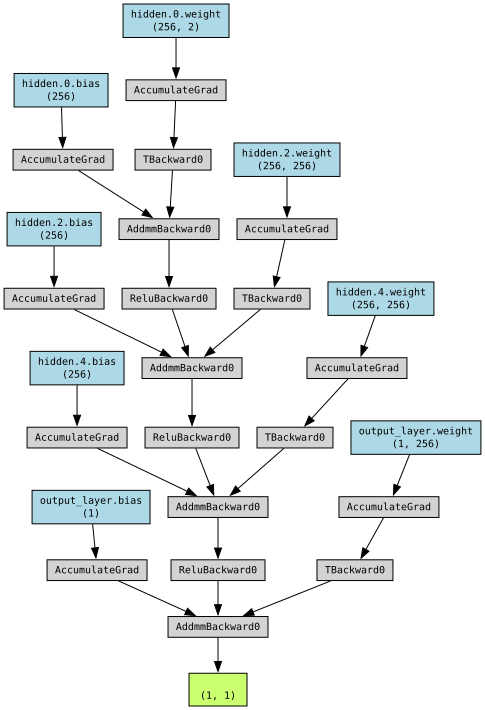

In [15]:
# visualize computational graph
x = torch.randn(1, num_features, device=device)
torchviz.make_dot(model(x), params=dict(model.named_parameters()))

### <img src="https://img.icons8.com/nolan/64/re-enter-pincode.png" style="height:50px;display:inline"> Weights Initialization
---
* As we have learned, neural networks are trained using a stochastic optimization algorithm, such as Gradient Descent, RMSprop, Adam and etc...
* Recall that these algorithms require initializing the parameters to some values. That is, they use randomness in order to find a good enough set of weights for the specific mapping function from inputs to outputs in your data that is being learned.
* These algroithms require that the weights of the network are initialized to small random values (random, but close to zero). 
    * Randomness is also used during the search process in the **shuffling of the training dataset** prior to each epoch, which in turn results in differences in the gradient estimate for each batch.
* Training deep models is a sufficiently difficult task that most algorithms are strongly affected by the choice of initialization (page 301, <a href="https://amzn.to/2H5wjfg">Deep Learning</a>, 2016).

#### Why Not Just Initialize With Zeros?
---
* We can use the same set of weights each time we train the network. For example, you could use the values of 0.0 for all weights.
* In this case, the equations of the learning algorithm would fail to make any changes to the network weights, and the model will be **stuck**. 
    * It is important to note that the bias weight in each neuron is set to zero by default, not a small random value.
* Specifically, neurons that are in the same hidden layer that is connected to the same inputs must have different weights for the learning algorithm to update the weights.
* **Symmetry Breaking**: initial parameters need to “break symmetry” between different units. If two hidden units with the same activation function are connected to the same inputs, then these units must have different initial parameters (page 301, <a href="https://amzn.to/2H5wjfg">Deep Learning</a>, 2016). 
    * Why? If they have the same initial parameters, then a deterministic learning algorithm applied to a deterministic cost and model will constantly update both of these units in the same way.
* Note that when you **constant the seed**, you will initialize with the same weights each time. We do this when we want to get reproducible results (or in production).

#### Recent Trend: Non-Random Initializations
---
* <a href="https://arxiv.org/abs/2007.01038">Beyond Signal Propagation: Is Feature Diversity Necessary in Deep Neural Network Initialization?</a>, a deep network is constructed with identical features by initializing almost all the weights to 0. The architecture also enables perfect signal propagation and stable gradients, and achieves high accuracy on standard benchmarks, indicating that random, diverse initializations are not always necessary for training neural networks.
* <a href="https://openreview.net/forum?id=1AxQpKmiTc">ZerO Initialization: Initializing Neural Networks with only Zeros and Ones</a>, the random weight initialization is replaced with a fully deterministic initialization scheme which initializes the weights of networks with only zeros and ones (up to a normalization factor), based on identity and Hadamard transforms. They show promising results on various benchmarks, paving the way to simpler initializations schemes that work just as well as random initializations.

### <img src="https://img.icons8.com/emoji/96/000000/on-arrow-emoji.png" style="height:50px;display:inline"> Types of Weight Initialization
---
<div style="width:100%;height:700px;line-height:3em;overflow:scroll;padding:5px;">

* The initialization of the weights of neural networks is an active field of study as the careful initialization of the network can speed up the learning process.

* There is no single best way to initialize the weights of a neural network.

* We will review some of the popular initalization methods.

* **Unifrom** - initialize with values drawn from the uniform distribution $\mathcal{U}(a, b)$
    * In PyTorch - `torch.nn.init.uniform_(tensor, a=0.0, b=1.0)`
* **Normal** - initialize with values drawn from the normal distribution $\mathcal{N}(\text{mean}, \text{std}^2)$
    * In PyTorch - `torch.nn.init.normal_(tensor, mean=0.0, std=1.0)`
* **Constant** - initialize with the value $val$.
    * In PyTorch - `torch.nn.init.constant_(tensor, val)`
* **Ones** - Initialize with the scalar value 1.
    * In PyTorch - `torch.nn.init.ones_(tensor)`
* **Zeros** - Initialize with the scalar value 0.
    * In PyTorch - `torch.nn.init.zeros_(tensor)`
 
* **Xavier (Glorot) Uniform** - Initialize with values according to the method described in *Understanding the difficulty of training deep feedforward neural networks - Glorot, X. & Bengio, Y. (2010)*, using a uniform distribution. The resulting tensor will have values sampled from $\mathcal{U}(-a, a)$ where $$ a = \text{gain} \times \sqrt{\frac{6}{\text{fan}_{in} + \text{fan}_{out}}} $$
    * `fan_in` is the number of input units in the weight tensor and `fan_out` is the number of output units in the weight tensor
    * In PyTorch - `torch.nn.init.xavier_uniform_(tensor, gain=1.0)`
    
* **Xavier (Glorot) Normal** - Initialize with values according to the method described in *Understanding the difficulty of training deep feedforward neural networks - Glorot, X. & Bengio, Y. (2010)*, using a normal distribution. The resulting tensor will have values sampled from $\mathcal{N}(0,\text{std}^2)$ where $$ \text{std} = \text{gain} \times \sqrt{\frac{2}{\text{fan}_{in} + \text{fan}_{out}}} $$
    * `fan_in` is the number of input units in the weight tensor and `fan_out` is the number of output units in the weight tensor
    * In PyTorch - `torch.nn.init.xavier_normal_(tensor, gain=1.0)`

* **Kaiming (He) Uniform** - Initialize with values according to the method described in *Delving deep into rectifiers: Surpassing human-level performance on ImageNet classification - He, K. et al. (2015)*, using a uniform distribution. The resulting tensor will have values sampled from $\mathcal{U}(-\text{bound}, \text{bound})$ where $$ \text{bound} = \text{gain} \times \sqrt{\frac{3}{\text{fan-mode}}} $$
    * In PyTorch - `torch.nn.init.kaiming_uniform_(tensor, a=0, mode='fan_in', nonlinearity='leaky_relu')`
    * `a` - the negative slope of the rectifier used after this layer (only used with `leaky_relu`)
    * `fan_mode` – either `fan_in` (default) or `fan_out`. Choosing `fan_in` preserves the magnitude of the variance of the weights in the forward pass. Choosing `fan_out` preserves the magnitudes in the backwards pass.
    * `nonlinearity` – the non-linear function (`nn.functional` name), recommended to use only with `relu` or `leaky_relu` (default).
    
* **Kaiming (He) Normal** - Initialize with values according to the method described in  *Delving deep into rectifiers: Surpassing human-level performance on ImageNet classification - He, K. et al. (2015)*, using a normal distribution. The resulting tensor will have values sampled from $\mathcal{N}(0,\text{std}^2)$ where $$ \text{std} = \frac{\text{gain}}{\sqrt{\text{fan-mode}}} $$
    * In PyTorch - `torch.nn.init.kaiming_normal_(tensor, a=0, mode='fan_in', nonlinearity='leaky_relu')`

PyTorch has default initializations schemes that usually work good. For example, `kaiming_uniform` is <a href="https://pytorch.org/docs/stable/_modules/torch/nn/modules/linear.html#Linear">the default initialization in PyTorch for `Linear` layers</a>:

</dov>


In [16]:
# pytorch default initialization for linear layers
def reset_parameters(module):
    # Setting a=sqrt(5) in kaiming_uniform is the same as initializing with
    # uniform(-1/sqrt(in_features), 1/sqrt(in_features)). For details, see
    # https://github.com/pytorch/pytorch/issues/57109
    torch.nn.init.kaiming_uniform_(module.weight, a=math.sqrt(5))
    if self.bias is not None:
        fan_in, _ = torch.nn.init._calculate_fan_in_and_fan_out(module.weight)
        bound = 1 / math.sqrt(fan_in) if fan_in > 0 else 0
        torch.nn.init.uniform_(module.bias, -bound, bound)

#### Interactive Demo
---
<a href="https://www.deeplearning.ai/ai-notes/initialization/">Different Initializations Demo</a>

### <img src="https://img.icons8.com/cotton/64/000000/olympic-torch.png" style="height:50px;display:inline"> Neural Network Weight Initialization with PyTorch
---
* As from PyTorch 1.0, **most layers are initialized using Kaiming Uniform method by default**.
* Let's see how we change the initialization of a model.
* <a href="https://pytorch.org/docs/stable/nn.init.html">Official PyTorch initialization documentation</a>.

In [17]:
# define hyper-parmeters and create our model
num_features = 2
output_dim = 1
batch_size = 128
learning_rate = 0.01
num_epochs = 500
# device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# loss criterion
criterion = nn.MSELoss()
# model
model = HousePricesMLP(num_features, output_dim).to(device)
# optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [18]:
# use a different initialization for the model
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Linear') != -1:
        torch.nn.init.xavier_normal_(m.weight, gain=1.0)
model.apply(weights_init)

HousePricesMLP(
  (hidden): Sequential(
    (0): Linear(in_features=2, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): ReLU()
  )
  (output_layer): Linear(in_features=256, out_features=1, bias=True)
)

In [19]:
# another way to do that
class HousePricesMLP(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(HousePricesMLP, self).__init__()
        self.hidden = nn.Sequential(nn.Linear(input_dim, 4),
                                    nn.ReLU(),
                                    nn.Linear(4, 3),
                                    nn.ReLU())
        self.output_layer = nn.Linear(3, output_dim)
        # NEW: init weights here
        self.init_weights()

    def forward(self, x):
        return self.output_layer(self.hidden(x))

    def init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                torch.nn.init.xavier_normal_(m.weight, gain=1.0)
                if m.bias is not None:
                    torch.nn.init.constant_(m.bias, 0)

In [20]:
boston_tensor_train_dataloader = DataLoader(boston_tensor_train_ds, batch_size=batch_size, shuffle=True)

# training loop for the model
for epoch in range(num_epochs):
    epoch_losses = []
    for features, targets in boston_tensor_train_dataloader:
        # send data to device
        features = features.to(device)
        targets = targets.to(device)
        # forward pass
        output = model(features)
        # loss
        loss = criterion(output.view(-1), targets)
        # backward pass
        optimizer.zero_grad()  # clean the gradients from previous iteration
        loss.backward()  # autograd backward to calculate gradients
        optimizer.step()  # apply update to the weights
        epoch_losses.append(loss.item())
    if epoch % 50 == 0:
        print(f'epoch: {epoch} loss: {np.mean(epoch_losses)}')
        
# test error
model.eval()
with torch.no_grad():
    test_outputs = model(torch.tensor(x_test, dtype=torch.float, device=device))
    test_error = criterion(test_outputs.view(-1), torch.tensor(y_test, dtype=torch.float, device=device))
print(f'test MSE error: {test_error.item()}')

epoch: 0 loss: 354.28736877441406
epoch: 50 loss: 27.957805395126343
epoch: 100 loss: 20.603639602661133
epoch: 150 loss: 16.338276386260986
epoch: 200 loss: 16.245474100112915
epoch: 250 loss: 23.33596682548523
epoch: 300 loss: 20.599802494049072
epoch: 350 loss: 23.49850869178772
epoch: 400 loss: 15.48305606842041
epoch: 450 loss: 15.223883986473083
test MSE error: 14.466264724731445


## <img src="https://img.icons8.com/bubbles/50/000000/alps.png" style="height:50px;display:inline"> Deep Double Descent
---
* Double Descent in ML algorithms training: performance first improves, then gets worse, and then improves again with increasing model size, data size, or training time.
* This effect is often avoided through careful **regularization** or **early stopping**. 
    * While this behavior appears to be fairly universal, *we don’t yet fully understand why it happens*.

<center><img src="./assets/double_descent_1.png" style="height:300px"></center>

* It can be seen that as we increase the number of parameters in a model, the test error initially decreases, increases, and, just as the model is able to fit the train set, undergoes a second descent. This is different than what we saw when we talked about the bias-variance trade-off.
* Double descent also occurs over **train epochs**. 
    * Surprisingly, it can lead to a regime where **more data hurts**, and training a deep network on a larger train set actually performs worse.

#### Model-wise Double Descent
---
* There is a regime where **bigger models are worse**.
* The model-wise double descent phenomenon can lead to a regime where training on more data hurts.

<center><img src="./assets/double_descent_model.svg" style="height:300px"></center>

In the figure, the peak in test error occurs around the interpolation threshold, **when the models are just barely large enough to fit the train set**.

#### Sample-wise Non-monotonicity
---
* There is a regime where **more samples hurts**.

<center><img src="./assets/double_descent_sample.svg" style="height:300px"></center>

* In the figure, increasing the number of samples shifts the curve downwards towards lower test error. 
* However, since more samples require larger models to fit, increasing the number of samples also shifts the interpolation threshold (and peak in test error) to the right.
* For intermediate model sizes (red arrows), these two effects combine, and training on 4.5x more samples actually hurts test performance.

#### Epoch-wise Double Descent
---
* There is a regime where **training longer reverses overfitting**.

<center><img src="./assets/double_descent_epoch.png" style="height:300px"></center>
<center><img src="./assets/double_descent_epoch_2.png" style="height:300px"></center>

* The figures above show test and train error as a function of both model size and number of optimization steps.
* For a given number of optimization steps (fixed y-coordinate), test and train error exhibit model-size double descent.
* For a given model size (fixed x-coordinate), as training proceeds, **test and train error decreases, increases, and decreases again!**

**In general, the peak of test error appears systematically when models are just barely able to fit the train set.**

### <img src="https://img.icons8.com/cotton/64/000000/stop-sign.png" style="height:50px;display:inline"> Question time!
---
This question appeared in Spring 2021 Moed A. 

<div style="display: flex; width: 100%;">
  <div style="width: 50%; padding-right: 10px;">
    <p>
        
You have to design an MLP with the following input: 
* DNA sequences of length $d$.
* The DNA is a sequence of bases, where each base can be one of 4 options: $(C, T, G, A)$.
* Thus, the input can be described as the following matrix: $$ X \in \mathcal{R}^{4 \times d}, $$ where $X[j,i]$ denotes the measured value of base concentration of the $j^{th}$ base at location $i$.
    </p>
  </div>
  <div style="width: 50%; padding-left: 10px;">
    
    <p><center><img src="./assets/DNA_sequence.png" style="width:100%"></center></p>
  </div>
</div>





The network should output a **binary** classification $y \in \{-1, 1\}$ for a specific property we wish to find. 

The network will be trained on samples $\{X^{(n)}, y^{(n)} \}_{n=1}^{N}$, with a **logistic loss function**.
$$l \left( y,  f_w(X) \right) = \log \left( 1 + \exp \left(- y  f_w(X) \right) \right)  $$

First, we will examine a network with 1 hidden layerof size $4 \times d$ and a **LeakyReLU** activation $\phi$: 
$$ f_w(X) = \sum_{r=1}^{4}\sum_{k=1}^d W_2[r,k]\phi\left(\sum_{j=1}^{4}\sum_{i=1}^d W_1[r, k,j, i]X[j, i] \right),$$
where $w=\{W_1, W_2\}$ are the layers of the weight **tensors**. 

After training is done, the classification will be done with $\text{sign}(f(X))$.

0. What are the dimensions of $W_1$ and $W_2$?
1. Which invariances exist in the network's parameters?
2. Now, we notice a fact regarding our data: <ins>The *direction* in which the DNA is scanned is arbitrary</ins>. Thus, if for two inputs $X, \tilde{X}$: $$ \forall i,j: \: X[j,i] = \tilde{X}[j, d-i+1], $$ then the two inputs are **equivalent** in their meaning. What constraints should we put on the network's parameters to improve the network's classification performance? Explain why using an **invariant hidden layer** is not optimal.

<!-- 4. After that, we now recall that the DNA bases come in pairs, and thus if for two inputs $X, \tilde{X}$: $$ \forall i,j : \: X[j,i] = \tilde{X}[(4-j)\text{mod}4 + 1,i] = \tilde{X}[5-j,i], $$ then the two inputs are **equivalent** in their meaning. What constraints should we put on the network's parameters to improve the network's classification performance?
 -->
3. We now notice that the measurement process in noisy, each sample $X^{(n)}$ is in arbitrary scale, and thus if for two $X, \tilde{X}$: $$ \forall i,j: \: X[j,i] = c\tilde{X}[j,i], $$ for some constant $c>0$, then the two inputs are **equivalent** in their meaning.
    * (a) For the given network, that **is already trained**, what is the effect of the scale $c$ on the classification result?
    * (b) Can the arbitrary scale hurt the training process? Hint: think what happens to the gradient of each sample.
    * (c) How can use this information to improve the classifier performance?

<!-- ### <img src="https://img.icons8.com/cotton/64/000000/checkmark.png" style="height:50px;display:inline"> Answer time!
---
<details>
  <summary>Hint</summary>

1. Consider the interactions of $W_1,W_2$ and the resulting symmetry.
2. The condition is straightforward.
3. Similar to section 2
4. What is or is not affected by scale?
    
</details>

<details>
  <summary>Solution</summary>

#### Section 1
We saw in the lecture MLP parameters have two types of invariances: Permutation invariance and Re-scale symmetry.
1. <ins>Permutation invariance</ins>:
    For any permutation matrix $P$,
   $$ W_l \rightarrow P W_l \,,\  W_{l+1} \rightarrow W_{l+1}P^{\top}\,,$$
   namely, swapping rows $i,j$ in $W_l$ and swapping columns $i,j$ in $W_{l+1}$ does not change the MLP.
   
3. <ins>Re-scale symmetry</ins> (for MLP with LReLU activaion):
    $$\forall c > 0 W_l \rightarrow c W_l \,,\  W_{l+1} \rightarrow \frac{1}{c} W_{l+1}\,,$$
   does not change the MLP.

Here, we Have:
1. Symmetry for permutation in the hidden layer - for each pair of indices $(j,i),(r,k)$, swapping 
$$W_1[i,j,:,:]\leftrightarrow W_1[r,k,:,:],\quad W_2[i,j] \leftrightarrow W_2[r,k] $$
does not change the outputs (permutation invariant).

2. Symmetry for multiplying and dividing by a constant, so the network output is transformation invariant
$$\forall r,k, c>0,\quad W_1[r,k,:,:]\rightarrow cW_1[r,k,:,:],\quad W_2[r,k] \rightarrow \frac{1}{c}W_2[r,k] $$

#### Section 2
Equivariance requires that applying the transform on both the input and output of $W_1$ does not change the tensor $W_1$, so 
$$\forall i,j,r,k, \quad W_1[r,k,:,:]=W_1[r,d+1-k,j,d+1-i]$$
For the output to be invariant to transformation, we must have 
$$\forall r,k, \quad W_2[r,k] \leftrightarrow W_2[r,d+1-k]$$
One can think of the second layer as a layer that preserves an equivariant representation that is followed by an average pooling. That is, we can define a tensor $\tilde{W}_2 \in \mathcal{R}^{4\times d \times 4 \times d}$ such that: $$ \forall i,j,k,r: \:\tilde{W}_2[j,i,r,k]=\tilde{W}_2[j, d-i + 1, r, d-k + 1] $$ $$W_2[r, k] = \frac{1}{4d}\sum_{j=1}^4\sum_{i=1}^d \tilde{W}_2[j,i,r,k], $$ and $(*)$ is true. **Why equivariance and not invariance?** In class, we learned that we need the hidden layer to be equivariant, and only before the output we will be invariant because even if the class itself is invariant to the transformation it doesn't entail that the hidden features are necessary invariant to the transformation. Why? Let's look at the specific case of reversing the DNA order: let's assume that the hidden layer is invariant, then $$ \forall i,j,k,r : W_1[k,r,j,i] = W_1[k,r,j,d+1-i], $$ which means we are giving the same weight to input $i$ and its complementary input $d+1-i$. Let's say there is an important feature in the form of the difference between two complementary inputs in every DNA, then we would not be able to detect it (it will be an eigenvector with eigenvalue 0 in $W_1$).

#### Section 3
Similar as the previous section, but for an additional transformation: $$ \forall i,j,k,r: \: W_1[k,r,j,i] = W_1[(4-r)\text{mod}4 + 1, k, (4-j)\text{mod}4 + 1, i] =  W_1[5-r, k, 5-j, i].$$ In addition, to constrain the network's output to be invariant to this transformation we demand: $$ \forall k,r: W_2[r,k]=W_2[(4-r)\text{mod}4 + 1, k]=W_2[5-r, k].$$

#### Section 4
a. There is no effect on classification, since $f(cX)=cf(X)$ and therefore $\mathrm{sign}(f(cX))=\mathrm{sign}(f(X))$.

b. Both the cost function and its gradient are affected by $c$:
$$\ell(y^{(n)},f_w(cX^{(n)}))=\log(1+\mathrm{exp}(-cy^{(n)}f_w(X^{(n)})))$$
$$\nabla_{w}\ell(y^{(n)},f_w(cX^{(n)}))=\frac{\mathrm{exp}(-cy^{(n)}f_w(X^{(n)}))}{1+\mathrm{exp}(-cy^{(n)}f_w(X^{(n)}))}(-cy^{(n)}\nabla_{w}f_w(X^{(n)}))=\frac{-cy^{(n)}}{1+\mathrm{exp}(cy^{(n)}f_w(X^{(n)}))}\nabla_{w}f_w(X^{(n)})$$
For the gradient, very small gradients for a very small $c$ and also for for samples with very large $c$ that are classified as true. On the other hand, we will get a very large gradient for samples that are classified as false for which $c$ is very large. Large arbitrary differences between the gradient's magnitudes can harm the training process.

c. We can just normalize the input:
$$f_w(X)=\sum_{r=1}^{4}\sum_{k=1}^{d}W_2[r,k]\varphi\left (\sum_{j=1}^{4}\sum_{i=1}^{d}W_1[r,k,j,i]\frac{X[j,i]}{\sqrt{\sum_{j'=1}^{4}\sum_{i'=1}^{d}X^2[j',i']}}\right )$$

</details> -->

### <img src="https://img.icons8.com/cotton/64/000000/checkmark.png" style="height:50px;display:inline"> Answer time!
---
<details>
  <summary>Hint</summary>

1. Consider the interactions of $W_1,W_2$ and the resulting symmetry.
2. The condition is straightforward.
3. Similar to section 2
4. What is or is not affected by scale?
    
</details>

#### Section 1
<span style="color:gray">
    $$ f_w(X) = \sum_{r=1}^{4}\sum_{k=1}^d W_2[r,k]\phi\left(\sum_{j=1}^{4}\sum_{i=1}^d W_1[r, k,j, i]X[j, i] \right),$$
Which invariances exist in the network's parameters?
</span>

We saw in the lecture MLP parameters have two types of invariances: Permutation invariance and Re-scale symmetry.
1. <ins>Permutation invariance</ins>:
    For any permutation matrix $P$,
   $$ W_l \rightarrow P W_l \,,\  W_{l+1} \rightarrow W_{l+1}P^{\top}\,,$$
   namely, swapping rows $i,j$ in $W_l$ and swapping columns $i,j$ in $W_{l+1}$ does not change the MLP.
   
3. <ins>Re-scale symmetry</ins> (for MLP with LReLU activaion):
    $$\forall c > 0 W_l \rightarrow c W_l \,,\  W_{l+1} \rightarrow \frac{1}{c} W_{l+1}\,,$$
   does not change the MLP.

Here, we Have:
1. Symmetry for permutation in the hidden layer - for each pair of indices $(j,i),(r,k)$, swapping 
$$W_1[i,j,:,:]\leftrightarrow W_1[r,k,:,:],\quad W_2[i,j] \leftrightarrow W_2[r,k] $$
does not change the outputs (permutation invariant).

2. Symmetry for multiplying and dividing by a constant, so the network output is transformation invariant
$$\forall r,k, c>0,\quad W_1[r,k,:,:]\rightarrow cW_1[r,k,:,:],\quad W_2[r,k] \rightarrow \frac{1}{c}W_2[r,k] $$

#### Section 2
<span style="color:gray">
Now, we notice a fact regarding our data: <ins>The direction in which the DNA is scanned is arbitrary</ins>. 
    
Thus, two inputs $X, \tilde{X}$ such that: $$ \forall i,j: \: X[j,i] = \tilde{X}[j, d-i+1], $$  are **equivalent** in their meaning. 

What constraints should we put on the network's parameters to improve the network's classification performance? 

</span>

<!-- #### 2. Directional-Invariance via Weight-Tying (MLP Intuition)

We flatten  
$$
X \in \mathbb{R}^{4\times d}
\;\longrightarrow\;
x \in \mathbb{R}^{4d},
$$  
so our MLP reads  
$$
f(x) \;=\; w_2^\top\,\phi\bigl(W_1\,x\bigr).
$$  
A flip of the DNA sequence (scanning in reverse) defines a permutation  
$$
P \in \{0,1\}^{4d\times4d}
\quad\text{with}\quad
(Px)_{(j,i)} = x_{(j,d-i+1)}.
$$  
We demand  
$$
f(Px) = f(x)
\quad\forall\,x,
$$  
**without** collapsing features by averaging. Instead, we **tie** weights so that applying $P$ before or after each layer is equivalent.

1. **First-layer tying**  
   $$
   W_1\,P = P\,W_1
   \;\Longrightarrow\;
   W_1[q,p] = W_1\bigl(P(q),\,P(p)\bigr).
   $$  
   In original indices $q=(r,k)$, $p=(j,i)$, this is  
   $$
   W_1[r,k,j,i]
   = W_1\bigl(r,\,d-k+1,\,j,\,d-i+1\bigr).
   $$

2. **Output-layer tying**  
   $$
   w_2^\top P = w_2^\top
   \;\Longrightarrow\;
   w_2[q] = w_2\bigl(P(q)\bigr),
   $$  
   i.e.  
   $$
   W_2[r,k] = W_2[r,d-k+1].
   $$

> **Why not pool hidden activations?**  
> Averaging  
> $$
> h^\mathrm{inv}_{r,k}
> = \tfrac12\bigl(h_{r,k} + h_{r,d-k+1}\bigr)
> $$  
> destroys distinct directional patterns.  
> **Weight-tying** enforces symmetry **while** preserving each filter’s unique nonlinear response.

<!-- #### 2. Directional‐Invariance via Weight Tying

We require  
$$f_w(X)=f_w(\tilde X),\quad \tilde X[j,i]=X[j,d-i+1].$$

1. **Flip operator**  
   Define $ M\in\mathbb R^{d\times d} $ by  
   $$
   M_{i,k} = 
   \begin{cases}
     1,&k=d-i+1,\\
     0,&\text{otherwise.}
   \end{cases}
   $$

2. **Equivariance Condition**  
   For each hidden‐filter slice \(W_1^{(r)}\in\mathbb R^{4\times d}\):  
   $$
   W_1^{(r)}\,M \;=\; M\,W_1^{(r)}.
   $$
   In index form:
   $$
   \sum_{i'}W_1[r,k,j,i']\,M_{i',i}
   \;=\;
   \sum_{k'}M_{k,k'}\,W_1[r,k',j,i]
   \;\Longrightarrow\;
   W_1[r,k,j,d-i+1] = W_1[r,d-k+1,j,i].
   $$

3. **Parameter-Tying Constraints**  
   Hence enforce
   $$
   \forall r,j,k,i:\quad
   W_1[r,k,j,i]
   = W_1[r,\,d-k+1,\,j,\,d-i+1],
   $$
   and for the output weights
   $$
   \forall r,k:\quad
   W_2[r,k] = W_2[r,\,d-k+1].
   $$

> **Why _not_ pool hidden activations?**  
> A naive invariant hidden layer might average
> \(\;h^\text{inv}_{r,k}=\tfrac12\bigl(h_{r,k}+h_{r,d-k+1}\bigr)\).  
> But this collapses distinct directional features and reduces nonlinear expressivity.  
> Weight-tying enforces symmetry while preserving each filter’s unique nonlinearity.  
 --> 

<!-- Equivariance requires that applying the transform on both the input and output of $W_1$ does not change the tensor $W_1$, so 
$$\forall i,j,r,k, \quad W_1[r,k,j,i]=W_1[r,d+1-k,j,d+1-i]$$ -->

We set constraint on $W_1$ and $W_2$ such that the hidden layer is equivariant to the scan order and the ouput is invariant to the scan order.
1. Equivariance requires that applying a transformation on the input of the layer is equivalent to applying it on the output.
Specifically here we would like the first layer to be equivariant to the "flipping" transformation:
$$W_1 \left(Mx \right) = M \left( W_1 x \right)$$
where (ignoring the bases dimensions),  $$
M = \begin{pmatrix}
& & & & 1 \\
& & & 1 & \\
& & \cdots & & \\
& 1 & & & \\
1 & & & & \\
\end{pmatrix}\, \ \  
   M_{i,k} = 
   \begin{cases}
     1,&k=d-i+1,\\
     0,&\text{otherwise.}
   \end{cases}
$$
Therefore we require 
$$W_1 M = MW_1\, $$ which gives the following constraints $${W}_{i,j} = {W}_{d + 1 - i, d + 1 - j}\,.$$
In our case the above constraints are relevant for the dimensions of the sequence in the input and output, therefore we require
$$\forall i,j,r,k, \quad W_1[r,k,j,i]=W_1[r,d+1-k,j,d+1-i]$$

2. For the output to be invariant to transformation, we must have 
$$\forall r,k, \quad W_2[r,k] \leftrightarrow W_2[r,d+1-k]$$

<!-- One can think of the second layer as a layer that preserves an equivariant representation that is followed by an average pooling. That is, we can define a tensor $\tilde{W}_2 \in \mathcal{R}^{4\times d \times 4 \times d}$ such that: $$ \forall i,j,k,r: \:\tilde{W}_2[j,i,r,k]=\tilde{W}_2[j, d-i + 1, r, d-k + 1] $$ $$W_2[r, k] = \frac{1}{4d}\sum_{j=1}^4\sum_{i=1}^d \tilde{W}_2[j,i,r,k], $$ and $(*)$ is true.  -->

**Why equivariance and not invariance?** In class, we learned that we need the hidden layer to be equivariant, and only before the output we will be invariant because even if the class itself is invariant to the transformation it doesn't entail that the hidden features are necessary invariant to the transformation. Why? Let's look at the specific case of reversing the DNA order: let's assume that the hidden layer is invariant, then $$ \forall i,j,k,r : W_1[k,r,j,i] = W_1[k,r,j,d+1-i], $$ which means we are giving the same weight to input $i$ and its complementary input $d+1-i$. Let's say there is an important feature in the form of the difference between two complementary inputs in every DNA, then we would not be able to detect it (it will be an eigenvector with eigenvalue 0 in $W_1$).

<!-- #### Section 3
<span style="color:gray">
</span> -->

<!-- Similar as the previous section, but for an additional transformation: $$ \forall i,j,k,r: \: W_1[k,r,j,i] = W_1[(4-r)\text{mod}4 + 1, k, (4-j)\text{mod}4 + 1, i] =  W_1[5-r, k, 5-j, i].$$ In addition, to constrain the network's output to be invariant to this transformation we demand: $$ \forall k,r: W_2[r,k]=W_2[(4-r)\text{mod}4 + 1, k]=W_2[5-r, k].$$ -->

#### Section 3
<span style="color:gray">

We now notice that the measurement process in noisy, each sample $X^{(n)}$ is in arbitrary scale, and thus if for two $X, \tilde{X}$: $$ \forall i,j: \: X[j,i] = c\tilde{X}[j,i], $$ for some constant $c>0$, then the two inputs are **equivalent** in their meaning.
    
* (a) For the given network, that **is already trained**, what is the effect of the scale $c$ on the classification result?
* (b) Can the arbitrary scale hurt the training process? Hint: think what happens to the gradient of each sample.
* (c) How can use this information to improve the classifier performance?
</span>

a. There is no effect on classification, since $f(cX)=cf(X)$ and therefore $\mathrm{sign}(f(cX))=\mathrm{sign}(f(X))$.

b. Both the cost function and its gradient are affected by $c$:
$$\ell(y^{(n)},f_w(cX^{(n)}))=\log(1+\mathrm{exp}(-cy^{(n)}f_w(X^{(n)}))) $$



$$\nabla_{w}\ell(y^{(n)},f_w(cX^{(n)}))=\frac{\mathrm{exp}(-cy^{(n)}f_w(X^{(n)}))}{1+\mathrm{exp}(-cy^{(n)}f_w(X^{(n)}))}(-cy^{(n)}\nabla_{w}f_w(X^{(n)}))=\frac{-cy^{(n)}}{1+\mathrm{exp}(cy^{(n)}f_w(X^{(n)}))}\nabla_{w}f_w(X^{(n)})$$

For the gradient, very small gradients for a very small $c$ and also for for samples with very large $c$ that are classified as true. On the other hand, we will get a very large gradient for samples that are classified as false for which $c$ is very large. Large arbitrary differences between the gradient's magnitudes can harm the training process.

c. We can just normalize the input:
$$f_w(X)=\sum_{r=1}^{4}\sum_{k=1}^{d}W_2[r,k]\varphi\left (\sum_{j=1}^{4}\sum_{i=1}^{d}W_1[r,k,j,i]\frac{X[j,i]}{\sqrt{\sum_{j'=1}^{4}\sum_{i'=1}^{d}X^2[j',i']}}\right )$$

### <img src="https://img.icons8.com/bubbles/50/000000/video-playlist.png" style="height:50px;display:inline"> Recommended Videos
---
#### <img src="https://img.icons8.com/cute-clipart/64/000000/warning-shield.png" style="height:30px;display:inline"> Warning!
* These videos do not replace the lectures and tutorials.
* Please use these to get a better understanding of the material, and not as an alternative to the written material.

#### Video By Subject

* Deep Learning - <a href="https://www.youtube.com/watch?v=kPXxbmBsFxs">Machine Learning Lecture 35 "Neural Networks / Deep Learning" -Cornell CS4780</a>
    * <a href="https://www.youtube.com/watch?v=zmu9wR2c7Z4">Machine Learning Lecture 36 "Neural Networks / Deep Learning Continued" -Cornell CS4780</a>
* Building a Network with PyTorch - <a href="https://www.youtube.com/watch?v=ixathu7U-LQ">Deep Learning and Neural Networks with Python and Pytorch</a>
* Weight Initialization - <a href="https://www.youtube.com/watch?v=m1gt7nxbB2k">UC Berkeley - STAT 157- Stabilize Training - Weight Initialization</a>
    * <a href="https://www.youtube.com/watch?v=tMjdQLylyGI">Krish Naik - Various Weight Initialization Techniques in Neural Network</a>
    * <a href="https://www.youtube.com/watch?v=s2coXdufOzE">Weight Initialization in a Deep Network (C2W1L11)</a>
* Deep Double Descent - <a href="https://www.youtube.com/watch?v=R29awq6jvUw">Henry AI Labs - Deep Double Descent</a>

## <img src="https://img.icons8.com/dusk/64/000000/prize.png" style="height:50px;display:inline"> Credits
---
* Icons made by <a href="https://www.flaticon.com/authors/becris" title="Becris">Becris</a> from <a href="https://www.flaticon.com/" title="Flaticon">www.flaticon.com</a>
* Icons from <a href="https://icons8.com/">Icons8.com</a> - https://icons8.com
* Datasets from <a href="https://www.kaggle.com/">Kaggle</a> - https://www.kaggle.com/
* <a href="https://machinelearningmastery.com/why-initialize-a-neural-network-with-random-weights/">Jason Brownlee - Why Initialize a Neural Network with Random Weights?</a>
* <a href="https://openai.com/blog/deep-double-descent/">OpenAI - Deep Double Descent</a>